In [2]:
from data_cleaning import thin_points, load_clean_data
from get_train_data import extract_satellite_data, scale_bands
import numpy as np
import pandas as pd

In [ ]:
#df = load_clean_data('data/caml_satellite_matchup.csv')

rows pre-cleaning: 23570
rows removed due to no sensor match: 10091
rows removed due to impossible band values: 332
rows removed due to spatial overlap: 3681
rows post-cleaning: 9466


In [3]:
df = pd.read_csv('data/caml_satellite_matchup_clean.csv').fillna(-999)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9180 entries, 0 to 9179
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               9180 non-null   int64  
 1   NIR                      9180 non-null   float64
 2   SWIR                     9180 non-null   float64
 3   blue                     9180 non-null   float64
 4   cyanobacteria_abundance  9180 non-null   float64
 5   green                    9180 non-null   float64
 6   longitude                9180 non-null   float64
 7   latitude                 9180 non-null   float64
 8   ndci                     9180 non-null   float64
 9   ndti                     9180 non-null   float64
 10  ndvi                     9180 non-null   float64
 11  ndwi                     9180 non-null   float64
 12  red                      9180 non-null   float64
 13  red_edge                 9180 non-null   float64
 14  sample_date             

In [5]:
from sklearn.model_selection import train_test_split

features = ['SWIR', 'blue', 'green', 'ndci', 'ndvi', 'ndti', 'red', 'red_edge', 'temp_c']
target = 'log_abundance'

X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Random Forest Regressor

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(n_estimators=100, random_state=42)
kf = KFold(n_splits=5, shuffle=False)

rf_r2 = cross_val_score(rf, X_train, y_train, cv=kf, scoring='r2')
rf_rmse = cross_val_score(rf, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print(f"R^2: {rf_r2.mean():.4f} ± {rf_r2.std():.4f}")
print(f"RMSE: {(-rf_rmse).mean():.4f} ± {(-rf_rmse).std():.4f}")

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.4011 ± 0.0065
RMSE: 1.0006 ± 0.0066
R^2: 0.3916
RMSE: 1.0106


<Axes: >

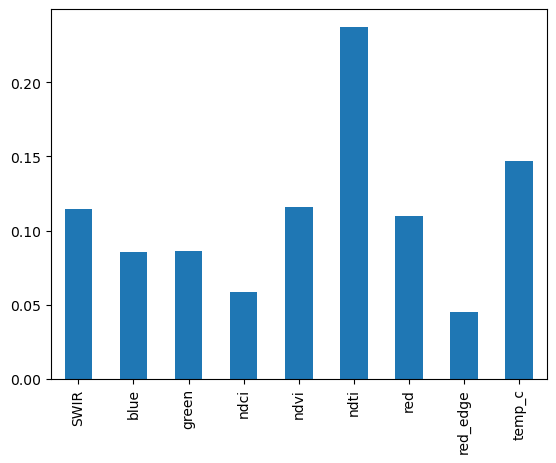

In [7]:
rf_feature_importances = pd.Series(rf.feature_importances_, index=features)

rf_feature_importances.plot.bar()

XGBoost

In [ ]:
import xgboost as xgb

xgboost = xgb.XGBRegressor(n_estimators=100, random_state=42)

xgb_r2 = cross_val_score(xgboost, X_train, y_train, cv=kf, scoring='r2')
xgb_rmse = cross_val_score(xgboost, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print(f"R^2: {xgb_r2.mean():.4f} ± {xgb_r2.std():.4f}")
print(f"RMSE: {(-xgb_rmse).mean():.4f} ± {(-xgb_rmse).std():.4f}")

xgboost.fit(X_train, y_train)
y_pred = xgboost.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.3474 ± 0.0124
RMSE: 1.0445 ± 0.0130
R^2: 0.3460
RMSE: 1.0478


MLP Regressor

In [14]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPRegressor(hidden_layer_sizes=(32, 32), activation='relu', max_iter=100, random_state=42)

mlp_r2 = cross_val_score(mlp, X_train_scaled, y_train, cv=kf, scoring='r2')
mlp_rmse = cross_val_score(mlp, X_train_scaled, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print(f"R^2: {mlp_r2.mean():.4f} ± {mlp_r2.std():.4f}")
print(f"RMSE: {(-mlp_rmse).mean():.4f} ± {(-mlp_rmse).std():.4f}")

mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


R^2: 0.3801 ± 0.0134
RMSE: 1.0179 ± 0.0097
R^2: 0.3768
RMSE: 1.0229


/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


SVR

In [15]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=10, epsilon=0.1)

svr_r2 = cross_val_score(svr, X_train_scaled, y_train, cv=kf, scoring='r2')
svr_rmse = cross_val_score(svr, X_train_scaled, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print(f"R^2: {svr_r2.mean():.4f} ± {svr_r2.std():.4f}")
print(f"RMSE: {(-svr_rmse).mean():.4f} ± {(-svr_rmse).std():.4f}")

svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.3383 ± 0.0040
RMSE: 1.0518 ± 0.0050
R^2: 0.3287
RMSE: 1.0616
